In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

MACHINE LEARNING MODEL BY LINEAR REGRESSION

In [149]:
df=pd.read_csv(r'C:\Users\Admin\Downloads\music_streaming_habits_2026.csv')
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


In [150]:
df.shape

(4000, 15)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listener_id              4000 non-null   int64  
 1   age                      4000 non-null   int64  
 2   country                  4000 non-null   object 
 3   platform                 4000 non-null   object 
 4   subscription             4000 non-null   object 
 5   top_genre                4000 non-null   object 
 6   top_artist               4000 non-null   object 
 7   daily_listening_minutes  4000 non-null   int64  
 8   songs_per_day            4000 non-null   int64  
 9   playlists_count          4000 non-null   int64  
 10  skip_rate_pct            4000 non-null   float64
 11  discover_weekly_user     4000 non-null   bool   
 12  top_mood                 4000 non-null   object 
 13  uses_offline_mode        4000 non-null   bool   
 14  podcasts_too            

In [152]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999    False
Length: 4000, dtype: bool

In [153]:
df.describe()

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,27.849000,138.702750,39.137500,8.994500,28.163375
std,1154.844867,8.595881,86.296023,25.046296,3.027914,11.815850
min,1.000000,13.000000,5.000000,1.000000,1.000000,0.000000
25%,1000.750000,22.000000,74.000000,21.000000,7.000000,20.000000
50%,2000.500000,28.000000,122.000000,35.000000,9.000000,28.100000
75%,3000.250000,34.000000,185.000000,52.250000,11.000000,36.300000
max,4000.000000,57.000000,697.000000,198.000000,22.000000,70.900000


In [154]:
df.columns

Index(['listener_id', 'age', 'country', 'platform', 'subscription',
       'top_genre', 'top_artist', 'daily_listening_minutes', 'songs_per_day',
       'playlists_count', 'skip_rate_pct', 'discover_weekly_user', 'top_mood',
       'uses_offline_mode', 'podcasts_too'],
      dtype='object')

In [155]:

df.corr(numeric_only=True)


,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,uses_offline_mode,podcasts_too
listener_id,1.000000,0.007889,-0.004164,-0.003563,-0.023307,-0.009755,0.010334,-0.000187,0.004857
age,0.007889,1.000000,-0.004767,-0.005350,-0.016720,-0.013811,-0.008738,-0.004280,-0.027359
daily_listening_minutes,-0.004164,-0.004767,1.000000,0.979688,0.008645,-0.031039,-0.008306,0.000857,-0.029402
songs_per_day,-0.003563,-0.005350,0.979688,1.000000,0.011739,-0.029484,-0.006422,0.001269,-0.031118
playlists_count,-0.023307,-0.016720,0.008645,0.011739,1.000000,0.015584,0.033282,0.006410,-0.025767
skip_rate_pct,-0.009755,-0.013811,-0.031039,-0.029484,0.015584,1.000000,0.009938,0.012688,-0.014738
discover_weekly_user,0.010334,-0.008738,-0.008306,-0.006422,0.033282,0.009938,1.000000,0.016638,-0.011173
uses_offline_mode,-0.000187,-0.004280,0.000857,0.001269,0.006410,0.012688,0.016638,1.000000,0.020984
podcasts_too,0.004857,-0.027359,-0.029402,-0.031118,-0.025767,-0.014738,-0.011173,0.020984,1.000000


ONE-HOT ENCODING

In [156]:
music= pd.get_dummies(df,drop_first=True)

In [157]:
music

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,uses_offline_mode,podcasts_too,country_Brazil,...,top_artist_The Weeknd,top_artist_Travis Scott,top_artist_Tyler the Creator,top_mood_Energetic,top_mood_Focus,top_mood_Happy,top_mood_Party,top_mood_Sad,top_mood_Sleep,top_mood_Workout
0,1,24,191,54,9,39.3,False,False,True,0,...,0,0,0,0,0,0,0,0,1,0
1,2,21,249,68,10,18.3,True,True,True,0,...,0,0,0,0,0,0,0,0,0,1
2,3,32,49,11,11,22.7,True,False,True,0,...,0,0,0,0,0,0,0,1,0,0
3,4,39,96,22,8,29.4,True,True,False,0,...,0,0,0,0,0,0,0,1,0,0
4,5,23,100,24,13,37.7,True,True,True,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,197,55,6,15.3,False,True,False,0,...,0,0,0,0,0,0,0,0,0,1
3996,3997,35,320,77,13,9.2,True,False,True,0,...,0,0,0,0,0,0,0,1,0,0
3997,3998,43,99,38,5,14.0,False,True,True,0,...,0,0,0,0,0,1,0,0,0,0
3998,3999,26,76,31,7,36.1,False,False,False,0,...,0,0,0,0,0,1,0,0,0,0


In [158]:
music.astype(int)

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,uses_offline_mode,podcasts_too,country_Brazil,...,top_artist_The Weeknd,top_artist_Travis Scott,top_artist_Tyler the Creator,top_mood_Energetic,top_mood_Focus,top_mood_Happy,top_mood_Party,top_mood_Sad,top_mood_Sleep,top_mood_Workout
0,1,24,191,54,9,39,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,2,21,249,68,10,18,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
2,3,32,49,11,11,22,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,4,39,96,22,8,29,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,5,23,100,24,13,37,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,197,55,6,15,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3996,3997,35,320,77,13,9,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3997,3998,43,99,38,5,14,0,1,1,0,...,0,0,0,0,0,1,0,0,0,0
3998,3999,26,76,31,7,36,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [159]:
df.columns

Index(['listener_id', 'age', 'country', 'platform', 'subscription',
       'top_genre', 'top_artist', 'daily_listening_minutes', 'songs_per_day',
       'playlists_count', 'skip_rate_pct', 'discover_weekly_user', 'top_mood',
       'uses_offline_mode', 'podcasts_too'],
      dtype='object')

In [160]:
from sklearn.preprocessing import StandardScaler
col=[ 'songs_per_day','playlists_count','skip_rate_pct']
scaler=StandardScaler()
music[col]=scaler.fit_transform(df[col])



In [161]:
from sklearn.model_selection import train_test_split
X=music.drop('daily_listening_minutes', axis=1)
y=music['daily_listening_minutes']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

MODEL CREATING

In [162]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](56,)","[ 0. , 0.01,84.4 ,..., 0.96, 0.15, 0.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](56,)","['listener_id','age','songs_per_day',...,'top_mood_Sad','top_mood_Sleep', 'top_mood_Workout']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,136.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,56
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,56


In [163]:
y_pred=model.predict(X_test)

PERFORMANCE ANALYSIS

In [164]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.958041919281193

In [165]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))

In [166]:
adjusted_r2

0.9561815451558935

In [167]:
y_pred

array([173.64583769,  79.32164147,  57.96981349, ...,  34.79618579,
        27.30826552,  91.13893251])

In [168]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5


In [169]:
mae


13.750891596056396

In [170]:
mse


301.4148918803739

In [171]:
rmse

17.361304440633887

Text(0.5, 1.0, 'actal vs prediction of daily listining minutes')

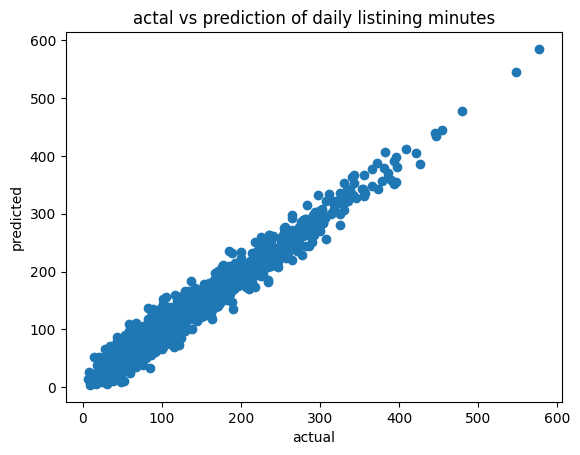

In [172]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("actal vs prediction of daily listining minutes")

In [173]:
coef=pd.DataFrame({'Feature':X.columns,'Coefficient':model.coef_})
top_coef=coef.sort_values("Coefficient",ascending=False)
top_coef

,Feature,Coefficient
2,songs_per_day,84.404499
26,top_genre_Country,2.607170
43,top_artist_Olivia Rodrigo,2.571640
30,top_genre_Jazz,2.489953
25,top_genre_Classical,2.170684
15,country_UK,2.065648
11,country_Germany,1.920035
32,top_genre_Lo-fi,1.877591
23,subscription_Premium,1.831621
14,country_Nigeria,1.762085


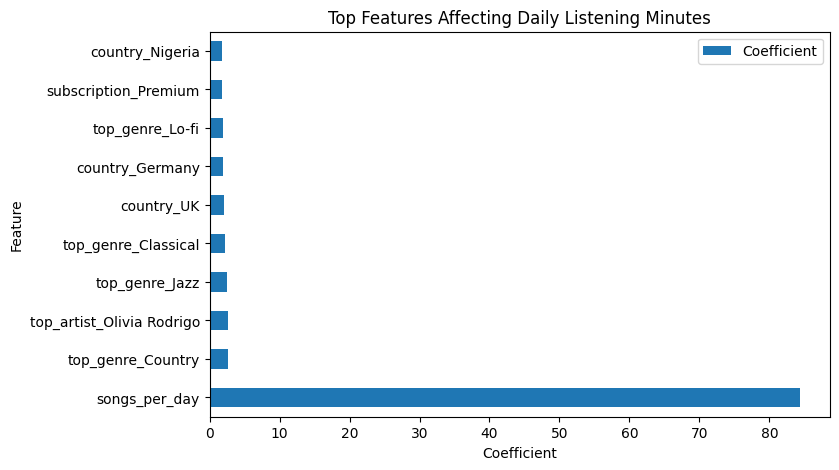

In [174]:
import matplotlib.pyplot as plt

top_coef.head(10).plot(x='Feature',y='Coefficient',kind='barh',figsize=(8,5))

plt.xlabel("Coefficient")
plt.title("Top Features Affecting Daily Listening Minutes")
plt.show()

IMPORT MODEL IN  .PKL FILE FOR STREAMLIT APP

In [175]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import joblib


# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


# Train
pipeline.fit(X_train, y_train)


# Evaluation
print("Train R2:", pipeline.score(X_train, y_train))
print("Test R2:", pipeline.score(X_test, y_test))


# Save pipeline
joblib.dump(
    pipeline,
    r"C:\Users\Admin\Downloads\music_pipeline.pkl"
)

print("Pipeline saved successfully")

Train R2: 0.9609660467131605
Test R2: 0.958041919281193
Pipeline saved successfully
